## How the corpus is organized

The dataset varies along four dimensions, and most of this notebook is about seeing how items distribute across them:

- **Family** — the kind of evidentiary image: **CCTV** (surveillance), **dashcam** (vehicle camera), or **phone** (handheld snapshot).
- **Tier** — how drastic the manipulation is: **T1** changes scene conditions (time of day, weather, lighting), **T2** adds or removes specific elements (a person, a vehicle, a sign), and **T3** is a wholly fabricated image generated from scratch.
- **Variant** — which generative model produced the item: **A** = GPT Image 2 (OpenAI), **B** = Gemini 3.1 + Nano Banana 2 (Google), **C** = Firefly 5 (Adobe, produced by hand in Photoshop).
- **Pool** — whether the item belongs to the **train** or **test** split. Crucially, the two splits never share a source image, so detectors are tested on genuinely unseen material.

## Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Point this at the manifest that ships with the dataset.
MANIFEST_PATH = Path(r"C:\Users\kelly.mcconvey\Documents\GitHub\Synthetic-Evidence-Image-Corpus\image_corpus_manifest.xlsx")

OUTPUT_DIR = Path("dataset_analysis_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

suffix = MANIFEST_PATH.suffix.lower()
if suffix in (".xlsx", ".xlsm"):
    df = pd.read_excel(MANIFEST_PATH)
elif suffix in (".csv", ".tsv"):
    df = pd.read_csv(MANIFEST_PATH, sep="\t" if suffix == ".tsv" else ",")
else:
    raise ValueError(f"Unsupported file type: {suffix}")

print(f"Loaded {len(df):,} items from {MANIFEST_PATH.name}")


Loaded 790 items from image_corpus_manifest.xlsx


In [ ]:
# Normalize the boolean tag columns (Excel sometimes stores these as strings).
for boolcol in ["flagged", "hero_candidate", "is_indoor",
                "has_clearly_visible_person", "has_open_floor_or_ground_space",
                "person_holding_object", "has_wall_signage_visible",
                "has_traffic_light_visible", "has_stop_sign_visible",
                "has_road_sign_visible", "has_clear_road_ahead",
                "has_visible_damage", "has_undamaged_surface_target",
                "has_handheld_object_visible", "has_open_surface_space"]:
    if boolcol in df.columns:
        df[boolcol] = (df[boolcol]
            .map({True: True, False: False, "True": True, "False": False,
                  "TRUE": True, "FALSE": False, 1: True, 0: False})
            .fillna(False))

# Friendly labels for the three model variants, used throughout.
VARIANT_LABELS = {"A": "GPT Image 2", "B": "Gemini 3.1", "C": "Firefly 5"}

def save_fig(fig, name):
    fig.savefig(OUTPUT_DIR / f"{name}.png", dpi=200, bbox_inches="tight")

print("Ready.")


## 1. Dataset Size

In [5]:
n_total = len(df)
print(f"The corpus contains {n_total:,} manipulated and fabricated images.")
print()
print(f"  Families:  {', '.join(sorted(df['family'].unique()))}")
print(f"  Tiers:     {', '.join(sorted(df['tier'].unique()))}")
print(f"  Variants:  {', '.join(VARIANT_LABELS.get(v, v) for v in sorted(df['assigned_variant'].unique()))}")
print(f"  Pools:     {', '.join(sorted(df['pool'].unique()))}")


The corpus contains 790 manipulated and fabricated images.

  Families:  cctv, dashcam, phone
  Tiers:     T1, T2, T3
  Variants:  GPT Image 2, Gemini 3.1, Firefly 5, Hero
  Pools:     test, train


### Items per model

Each of the three generative models contributes a roughly equal share. That balance is deliberate: a central use of this corpus is comparing how different models' outputs are detected, and that comparison is only fair if no single model dominates the data.

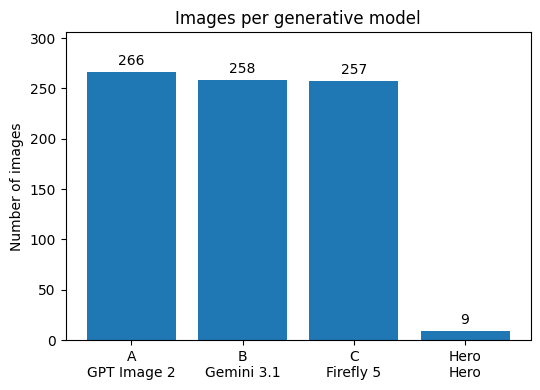

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
vc = df["assigned_variant"].value_counts().sort_index()
labels = [f"{v}\n{VARIANT_LABELS.get(v, v)}" for v in vc.index]
bars = ax.bar(labels, vc.values)
ax.bar_label(bars, padding=3)
ax.set_ylabel("Number of images")
ax.set_title("Images per generative model")
ax.set_ylim(0, vc.max() * 1.15)
save_fig(fig, "fig_variant_balance")
plt.show()


### Items by family and tier

This is the backbone of the corpus. Reading the chart: each family (CCTV, dashcam, phone) gets the same treatment, and within each, the three tiers represent escalating degrees of manipulation. T1 and T2 are larger than T3 because they draw on real source frames (of which there are many), while T3 fabricates from scratch.

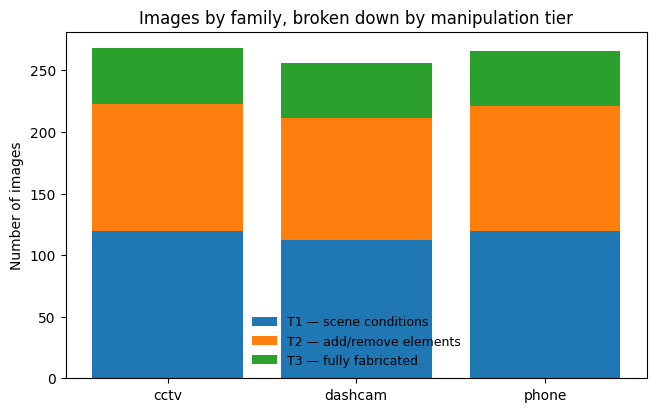


The same breakdown as a table:


tier,T1,T2,T3,Total
family,,,,
cctv,120,103,45,268
dashcam,112,99,45,256
phone,120,101,45,266
Total,352,303,135,790


In [7]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
tiers = sorted(df["tier"].unique())
families = sorted(df["family"].unique())
tier_names = {"T1": "T1 — scene conditions", "T2": "T2 — add/remove elements", "T3": "T3 — fully fabricated"}
bottom = np.zeros(len(families))
for tier in tiers:
    counts = [len(df[(df["family"] == fam) & (df["tier"] == tier)]) for fam in families]
    ax.bar(families, counts, bottom=bottom, label=tier_names.get(tier, tier))
    bottom += np.array(counts)
ax.set_ylabel("Number of images")
ax.set_title("Images by family, broken down by manipulation tier")
ax.legend(frameon=False, fontsize=9)
save_fig(fig, "fig_family_tier_stacked")
plt.show()

# The underlying table
ft = df.pivot_table(index="family", columns="tier", values="frame_id",
                    aggfunc="count", fill_value=0, margins=True, margins_name="Total")
print("\nThe same breakdown as a table:")
display(ft)


## 2. Images Sources

Every manipulated image (T1 and T2) starts life as a real photograph from an established public dataset. The fabricated images (T3) have no source; they're generated entirely from a text prompt.

The source datasets are:
- **VIRAT** and **UCF-Crime** (normal-activity footage only) for surveillance frames,
- **BDD100K** for dashcam stills,
- **CASIA** for phone-style photographs.

The CCTV family is a mix of two surveillance sources rather than relying on one, so that a detector can't simply learn to recognize "this looks like VIRAT" instead of learning to spot the manipulation itself.

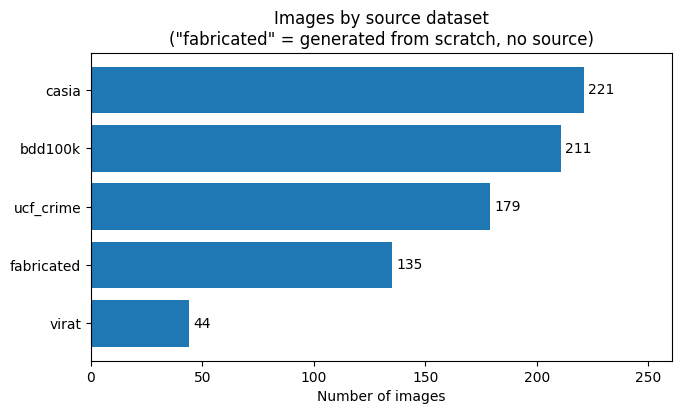

In [8]:
if "dataset" in df.columns:
    ds = df["dataset"].value_counts()
    fig, ax = plt.subplots(figsize=(7.5, 4))
    bars = ax.barh(ds.index[::-1], ds.values[::-1])
    ax.bar_label(bars, padding=3)
    ax.set_xlabel("Number of images")
    ax.set_title("Images by source dataset\n(\"fabricated\" = generated from scratch, no source)")
    ax.set_xlim(0, ds.max() * 1.18)
    save_fig(fig, "fig_source_dataset")
    plt.show()


In [9]:
if "dataset" in df.columns:
    cctv = df[(df["family"] == "cctv") & (df["tier"] != "T3")]
    if len(cctv):
        mix = cctv["dataset"].value_counts()
        total = mix.sum()
        print("CCTV substrate is drawn from two surveillance sources:")
        for src, n in mix.items():
            print(f"   {src}: {n} images ({n/total*100:.1f}%)")
        virat_pct = mix.get("virat", 0) / total * 100 if total else 0
        print()
        if abs(virat_pct - 60) <= 10:
            print(f"The realized mix is close to the intended ~60/40 VIRAT-majority blend.")
        else:
            print(f"Note: the realized VIRAT share ({virat_pct:.1f}%) differs from the ~60% the")
            print(f"design aimed for. This reflects how many usable frames each source yielded")
            print(f"under the tag requirements — worth knowing if you analyze the two sources separately.")


CCTV substrate is drawn from two surveillance sources:
   ucf_crime: 179 images (80.3%)
   virat: 44 images (19.7%)

Note: the realized VIRAT share (19.7%) differs from the ~60% the
design aimed for. This reflects how many usable frames each source yielded
under the tag requirements — worth knowing if you analyze the two sources separately.


## 3. Source Image Descriptions

Before any manipulation, every source frame was automatically tagged with descriptive attributes — time of day, weather, lighting, how many people are present, and so on. These tags served a practical purpose during construction , but they also reveal the *visual diversity* of the corpus.

A few patterns below are worth anticipating: surveillance and dashcam footage skews heavily toward ordinary daytime, clear-weather conditions, simply because that's what most real footage is. The corpus reflects the world it was drawn from rather than an artificially uniform spread.

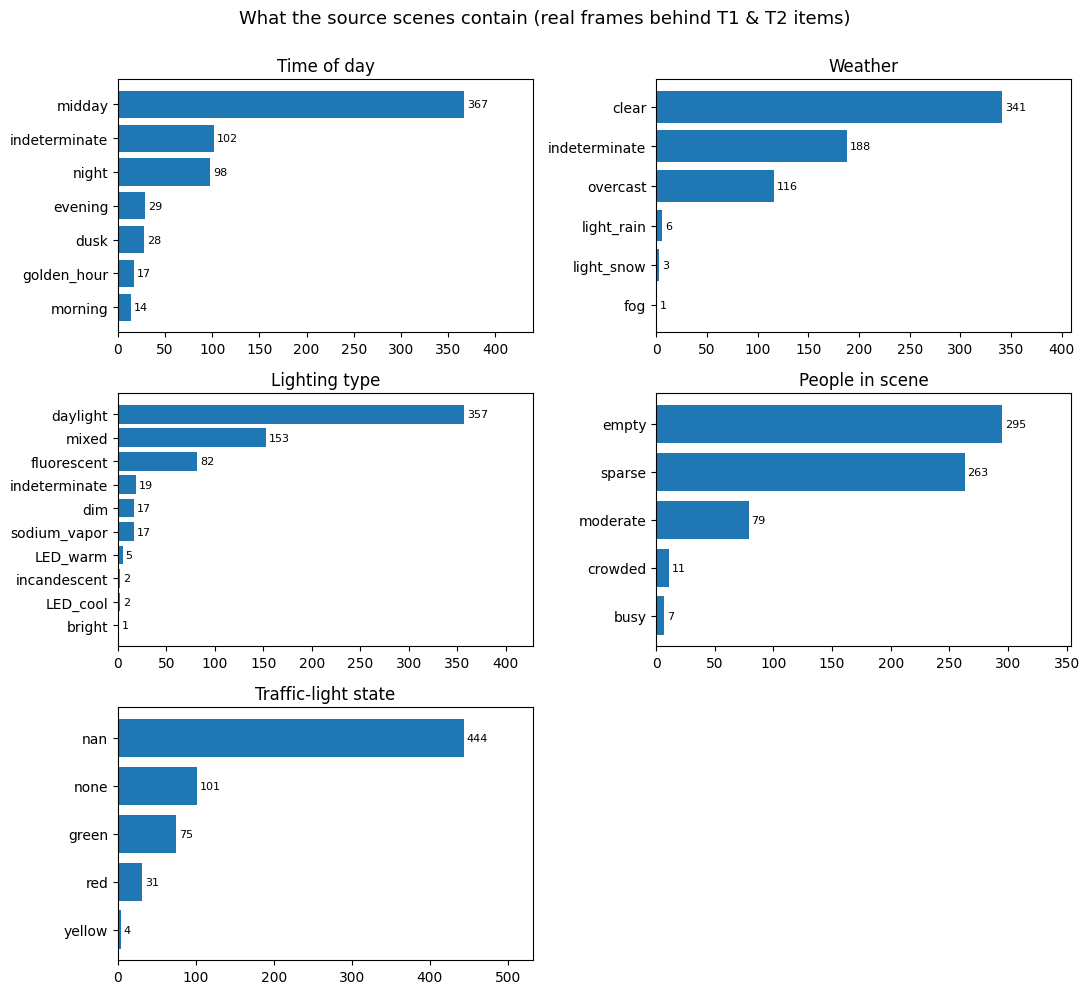

In [10]:
src_df = df[df["tier"].isin(["T1", "T2"])].copy()  # source-based items only

CATEGORICAL_TAGS = [t for t in ["time_of_day", "weather", "lighting_type",
                                "people_count_bucket", "traffic_light_state"]
                    if t in src_df.columns]

ncols = 2
nrows = int(np.ceil(len(CATEGORICAL_TAGS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(11, 3.3 * nrows))
axes = np.array(axes).reshape(-1)
nice = {"time_of_day": "Time of day", "weather": "Weather",
        "lighting_type": "Lighting type", "people_count_bucket": "People in scene",
        "traffic_light_state": "Traffic-light state"}
for i, tag in enumerate(CATEGORICAL_TAGS):
    ax = axes[i]
    vc = src_df[tag].value_counts(dropna=False)
    idx = [str(x) for x in vc.index]
    bars = ax.barh(idx[::-1], vc.values[::-1])
    ax.set_title(nice.get(tag, tag))
    ax.bar_label(bars, padding=2, fontsize=8)
    ax.set_xlim(0, vc.max() * 1.2)
for j in range(len(CATEGORICAL_TAGS), len(axes)):
    axes[j].set_visible(False)
fig.suptitle("What the source scenes contain (real frames behind T1 & T2 items)",
             y=1.0, fontsize=13)
fig.tight_layout()
save_fig(fig, "fig_substrate_attributes")
plt.show()


## 4. Types of Manipulations

This is the heart of the corpus. Every item was produced from a prompt template — a specific instruction like "shift the time of day to night" or "remove the stop sign." There are 27 distinct templates spanning the three tiers and three families. The chart below shows how many images each template produced.

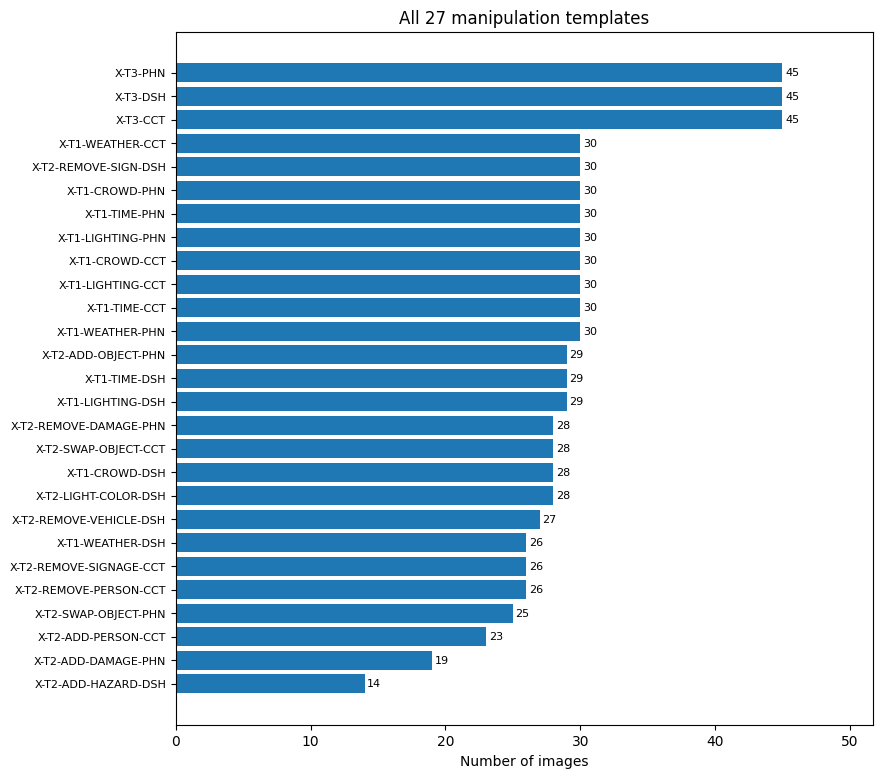

In [11]:
if "assigned_prompt_template" in df.columns:
    tmpl = df["assigned_prompt_template"].value_counts().sort_values()
    fig, ax = plt.subplots(figsize=(9, 9))
    bars = ax.barh(tmpl.index, tmpl.values)
    ax.bar_label(bars, padding=2, fontsize=8)
    ax.set_xlabel("Number of images")
    ax.set_title(f"All {len(tmpl)} manipulation templates")
    ax.set_xlim(0, tmpl.max() * 1.15)
    ax.tick_params(axis="y", labelsize=8)
    save_fig(fig, "fig_template_usage")
    plt.show()


### The directions of change in Tier 1

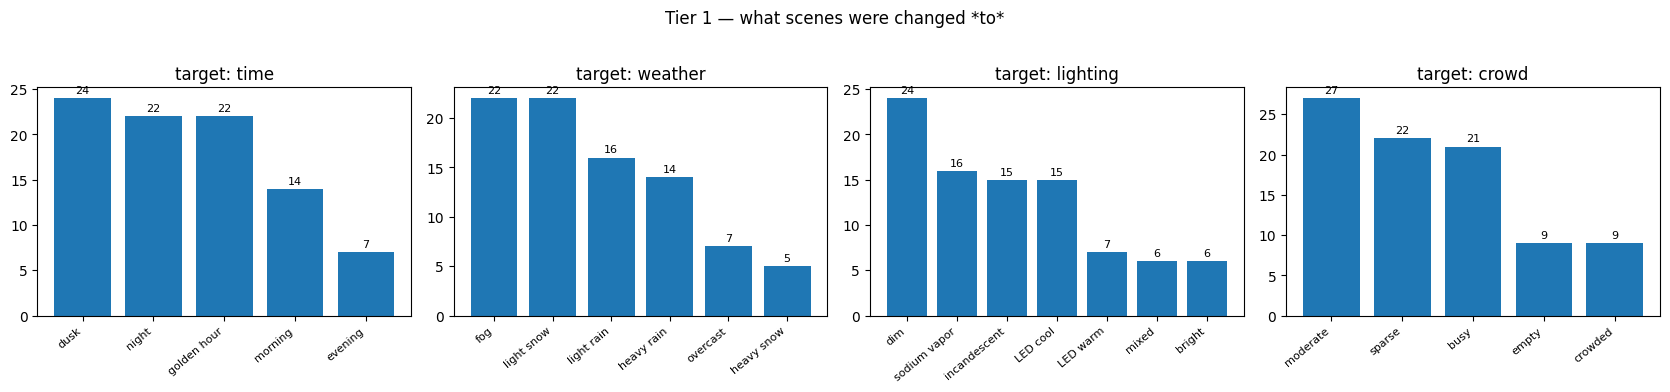

In [12]:
T1_TARGETS = [c for c in ["target_time", "target_weather", "target_lighting", "target_crowd"]
              if c in df.columns]
present = [c for c in T1_TARGETS if df[c].notna().any()]
if present:
    fig, axes = plt.subplots(1, len(present), figsize=(4.2 * len(present), 3.8))
    if len(present) == 1:
        axes = [axes]
    for ax, col in zip(axes, present):
        sub = df[df[col].notna()]
        vc = sub[col].value_counts()
        bars = ax.bar(range(len(vc)), vc.values)
        ax.set_xticks(range(len(vc)))
        ax.set_xticklabels(vc.index, rotation=40, ha="right", fontsize=8)
        ax.set_title(col.replace("target_", "target: "))
        ax.bar_label(bars, padding=2, fontsize=8)
    fig.suptitle("Tier 1 — what scenes were changed *to*", y=1.02)
    fig.tight_layout()
    save_fig(fig, "fig_t1_targets")
    plt.show()


### The full composition table

This is the master breakdown of the manipulated portion of the corpus: every family, its source dataset(s), and the per-subtype counts for each tier. Tier 1 (scene conditions) and Tier 2 (element edits) are each split into their family-specific subtypes; Tier 3 is the count of fully fabricated images. This is the table that appears in the paper.

Because the corpus enforces no source-frame reuse, the per-subtype counts are not perfectly uniform — they reflect how many usable source frames each subtype's requirements actually yielded. The counts below are computed directly from the manifest.

In [13]:
# Human-readable labels for the subtype codes
T1_LABELS = {
    "TIME": "Time of day", "WEATHER": "Weather",
    "LIGHTING": "Lighting", "CROWD": "Crowd density",
}
T2_LABELS = {
    "ADD-PERSON": "Add person", "REMOVE-PERSON": "Remove person",
    "REMOVE-SIGNAGE": "Remove signage", "SWAP-OBJECT-CCT": "Swap object",
    "ADD-HAZARD": "Add hazard", "LIGHT-COLOR": "Traffic-light color",
    "REMOVE-SIGN-DSH": "Remove sign", "REMOVE-VEHICLE": "Remove vehicle",
    "ADD-OBJECT": "Add object", "ADD-DAMAGE": "Add damage",
    "REMOVE-DAMAGE": "Remove damage", "SWAP-OBJECT-PHN": "Swap object",
}
FAMILY_LABELS = {"cctv": "Surveillance (CCTV)", "dashcam": "Dashcam", "phone": "Consumer photos"}

# Which source dataset(s) feed each family — read from the data itself.
def sources_for_family(fam):
    s = df[(df["family"] == fam) & (df["tier"] != "T3")]["dataset"].value_counts()
    return ", ".join(s.index) if len(s) else "-"

# Build one tidy row per (family, subtype) showing T1 and T2 counts side by side,
# plus a family-level T3 total.
families = ["cctv", "dashcam", "phone"]
rows = []
for fam in families:
    fam_df = df[df["family"] == fam]
    t1 = fam_df[fam_df["tier"] == "T1"]["t1_subtype"].value_counts()
    t2 = fam_df[fam_df["tier"] == "T2"]["t2_subtype"].value_counts()
    t3_n = int((fam_df["tier"] == "T3").sum())

    # Order subtypes consistently
    t1_items = [(T1_LABELS.get(k, k), int(v)) for k, v in
                sorted(t1.items(), key=lambda kv: list(T1_LABELS).index(kv[0]) if kv[0] in T1_LABELS else 99)]
    t2_items = [(T2_LABELS.get(k, k), int(v)) for k, v in sorted(t2.items(), key=lambda kv: -kv[1])]

    n_lines = max(len(t1_items), len(t2_items))
    for i in range(n_lines):
        t1_label, t1_n = t1_items[i] if i < len(t1_items) else ("", "")
        t2_label, t2_n = t2_items[i] if i < len(t2_items) else ("", "")
        rows.append({
            "Family": FAMILY_LABELS.get(fam, fam) if i == 0 else "",
            "Source(s)": sources_for_family(fam) if i == 0 else "",
            "T1 subtype": t1_label, "T1 n": t1_n,
            "T2 subtype": t2_label, "T2 n": t2_n,
            "T3 (fab.)": t3_n if i == 0 else "",
            "Family total": int(len(fam_df)) if i == 0 else "",
        })

composition = pd.DataFrame(rows)
display(composition)

# Per-tier totals across the whole manipulated corpus
t1_total = int((df["tier"] == "T1").sum())
t2_total = int((df["tier"] == "T2").sum())
t3_total = int((df["tier"] == "T3").sum())
manip_total = t1_total + t2_total + t3_total
print(f"Per-tier totals:  T1 = {t1_total}   T2 = {t2_total}   T3 = {t3_total}")
print(f"Total manipulated items: {manip_total}")

# Save for the paper
composition.to_csv(OUTPUT_DIR / "table_composition.csv", index=False)


,Family,Source(s),T1 subtype,T1 n,T2 subtype,T2 n,T3 (fab.),Family total
0,Surveillance (CCTV),"ucf_crime, virat",Time of day,30,Swap object,28,45,268
1,,,Weather,30,Remove person,26,,
2,,,Lighting,30,Remove signage,26,,
3,,,Crowd density,30,Add person,23,,
4,Dashcam,bdd100k,Time of day,29,Remove sign,30,45,256
5,,,Weather,26,Traffic-light color,28,,
6,,,Lighting,29,Remove vehicle,27,,
7,,,Crowd density,28,Add hazard,14,,
8,Consumer photos,casia,Time of day,30,Add object,29,45,266
9,,,Weather,30,Remove damage,28,,


Per-tier totals:  T1 = 352   T2 = 303   T3 = 135
Total manipulated items: 790


### LaTeX version of the composition table

The cell below emits the table body in the format used in the paper, with the real counts filled in — so you can paste it straight into the LaTeX `tabular` rather than transcribing numbers by hand. Only the data rows are generated; the surrounding `table*` / caption / `\toprule` scaffolding lives in the paper.

In [ ]:
# Emit LaTeX table-body rows with real counts, matching the paper's layout.
def latex_rows():
    families = ["cctv", "dashcam", "phone"]
    src_label = {"cctv": r"VIRAT, UCF-Crime", "dashcam": "BDD100K", "phone": "CASIA"}
    fam_label = {"cctv": r"Surveillance\\(\\textsc{cctv})", "dashcam": "Dashcam", "phone": r"Consumer\\photos"}
    out = []
    for fam in families:
        fam_df = df[df["family"] == fam]
        t1 = fam_df[fam_df["tier"] == "T1"]["t1_subtype"].value_counts()
        t2 = fam_df[fam_df["tier"] == "T2"]["t2_subtype"].value_counts()
        t3_n = int((fam_df["tier"] == "T3").sum())
        fam_total = int(len(fam_df))

        t1_order = ["TIME", "WEATHER", "LIGHTING", "CROWD"]
        t1_items = [(T1_LABELS[k], int(t1.get(k, 0))) for k in t1_order]
        t2_items = [(T2_LABELS.get(k, k), int(v)) for k, v in sorted(t2.items(), key=lambda kv: -kv[1])]

        n = max(len(t1_items), len(t2_items))
        for i in range(n):
            t1_l, t1_v = t1_items[i] if i < len(t1_items) else ("", "")
            t2_l, t2_v = t2_items[i] if i < len(t2_items) else ("", "")
            if i == 0:
                fam_cell = r"\multirow{%d}{*}{\parbox{2.0cm}{%s}}" % (n, fam_label[fam])
                src_cell = r"\multirow{%d}{*}{\parbox{2.5cm}{%s}}" % (n, src_label[fam])
                t3_cell = r"\multirow{%d}{*}{%d}" % (n, t3_n)
                tot_cell = r"\multirow{%d}{*}{\textbf{%d}}" % (n, fam_total)
            else:
                fam_cell = src_cell = t3_cell = tot_cell = ""
            out.append(f"{fam_cell} & {src_cell} & {t1_l} & {t1_v} & {t2_l} & {t2_v} & {t3_cell} & {tot_cell} \\\\")
        out.append(r"\cmidrule(lr){1-8}")
    return "\n".join(out)

print(latex_rows())

t1_total = int((df["tier"] == "T1").sum())
t2_total = int((df["tier"] == "T2").sum())
t3_total = int((df["tier"] == "T3").sum())
print(f"\n% Per-tier totals: T1={t1_total}, T2={t2_total}, T3={t3_total}, all={t1_total+t2_total+t3_total}")


## 5. Train/test split

The corpus guards against source leakage by splitting at the level of the source video *before* any frames are extracted. The check below confirms that no source video appears in both pools, and that no individual frame is reused anywhere.

In [15]:
if "pool" in df.columns:
    pc = df["pool"].value_counts()
    print("Split sizes:")
    for p, n in pc.items():
        print(f"   {p}: {n} images ({n/len(df)*100:.1f}%)")
    print()

    if "source_video_id" in df.columns:
        spanning = (df[df["source_video_id"].notna()]
                    .groupby("source_video_id")["pool"].nunique())
        leaked = spanning[spanning > 1]
        if len(leaked) == 0:
            print("PASS: no source video appears in both train and test.")
            print("      The split is clean — test material is genuinely unseen.")
        else:
            print(f"WARNING: {len(leaked)} source video(s) appear in both pools.")

    dups = df[df["frame_id"].notna()]["frame_id"].duplicated().sum()
    print(f"\nDuplicate source frames across the whole corpus: {dups}")
    if dups == 0:
        print("      Every source frame is used at most once — no frame is reused.")


Split sizes:
   train: 553 images (70.0%)
   test: 237 images (30.0%)

PASS: no source video appears in both train and test.
      The split is clean — test material is genuinely unseen.

Duplicate source frames across the whole corpus: 0
      Every source frame is used at most once — no frame is reused.


## 6. The corpus at a glance

In [16]:
print("=" * 52)
print("  THE CIFAR SYNTHETIC EVIDENCE CORPUS — IMAGE DATASET")
print("=" * 52)
print(f"  Total images:        {len(df):,}")
print(f"  Evidence families:   {df['family'].nunique()}  ({', '.join(sorted(df['family'].unique()))})")
print(f"  Manipulation tiers:  {df['tier'].nunique()}")
print(f"  Generative models:   {df['assigned_variant'].nunique()}")
print(f"  Manipulation types:  {df['assigned_prompt_template'].nunique()} distinct templates")
if "dataset" in df.columns:
    print(f"  Source datasets:     {df[df['dataset'] != 'fabricated']['dataset'].nunique()}")
if "pool" in df.columns:
    tr = (df['pool'] == 'train').sum(); te = (df['pool'] == 'test').sum()
    print(f"  Train / test split:  {tr:,} / {te:,}")
print("  Per tier:            " + ",  ".join(f"{t}: {n}" for t, n in df['tier'].value_counts().sort_index().items()))
print("=" * 52)
print()
print("  If you use this dataset, please see the repository README for citation and license details.")


  THE CIFAR SYNTHETIC EVIDENCE CORPUS — IMAGE DATASET
  Total images:        790
  Evidence families:   3  (cctv, dashcam, phone)
  Manipulation tiers:  3
  Generative models:   4
  Manipulation types:  27 distinct templates
  Source datasets:     4
  Train / test split:  553 / 237
  Per tier:            T1: 352,  T2: 303,  T3: 135

  If you use this dataset, please see the repository README for citation and license details.
